# monitoring the current window

A model is serving now, so the question shifts from "is it accurate" to "is the
world still the one it was trained on". The current window (Sep–Nov) is later in
time and almost entirely autumn — a season the training window never saw — so I
expect both input drift and a drop in quality. This notebook is the manual version
of what `monitor.py` checks on a schedule.

In [1]:
import sys
sys.path.insert(0, "../src")

import yaml
import numpy as np
import pandas as pd
import lightgbm as lgb
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import mean_absolute_error, mean_squared_error

from seoul_bike_mlops.features import engineer_features
from evidently import DataDefinition, Dataset, Regression, Report
from evidently.presets import DataDriftPreset, RegressionPreset

sns.set_theme(style="whitegrid")

NUMERICAL = ["hour", "temperature", "humidity", "wind_speed", "visibility",
             "solar_radiation", "rainfall", "snowfall"]
CATEGORICAL = ["season", "holiday"]
TARGET = "rented_bike_count"

ref = pd.read_csv("../data/processed/reference.csv", parse_dates=["date"])
cur = pd.read_csv("../data/processed/current.csv", parse_dates=["date"])
ref = ref[ref["functioning_day"] == "Yes"].reset_index(drop=True)
cur = cur[cur["functioning_day"] == "Yes"].reset_index(drop=True)
len(ref), len(cur)

(6528, 1937)

## what drifted

Same Evidently check the monitor script runs. The summary metric counts how many
of the monitored features moved; per-column scores tell me which ones.

In [2]:
booster = lgb.Booster(model_file="../models/lgbm.txt")
feat_names = booster.feature_name()
log_target = yaml.safe_load(open("../params.yaml"))["train"]["log_target"]

def score(df):
    feats = engineer_features(df).reindex(columns=feat_names, fill_value=0)
    pred = booster.predict(feats)
    if log_target:
        pred = np.expm1(pred)
    return np.clip(pred, 0, None)

ref_s = ref[NUMERICAL + CATEGORICAL + [TARGET]].copy()
cur_s = cur[NUMERICAL + CATEGORICAL + [TARGET]].copy()
ref_s["prediction"] = score(ref)
cur_s["prediction"] = score(cur)

dd = DataDefinition(numerical_columns=NUMERICAL, categorical_columns=CATEGORICAL,
                    regression=[Regression(target=TARGET, prediction="prediction")])
rep = Report(metrics=[DataDriftPreset(), RegressionPreset()])
res = rep.run(current_data=Dataset.from_pandas(cur_s, data_definition=dd),
              reference_data=Dataset.from_pandas(ref_s, data_definition=dd))

rows = []
for m in res.dict()["metrics"]:
    cfg = m["config"]
    if cfg["type"].endswith("ValueDrift"):
        rows.append((cfg["column"], round(float(m["value"]), 3)))
drift = pd.DataFrame(rows, columns=["column", "drift_score"]).sort_values("drift_score", ascending=False)
drift

,column,drift_score
8,season,0.833
1,temperature,0.410
3,wind_speed,0.287
4,visibility,0.262
7,snowfall,0.107
2,humidity,0.099
5,solar_radiation,0.070
6,rainfall,0.036
0,hour,0.004
9,holiday,0.003


## the seasonal shift

This is the obvious driver. The training window has no autumn at all; the current
window is almost nothing else. Temperature shifts with it.

reference seasons: {'Summer': 2208, 'Winter': 2160, 'Spring': 2160}
current seasons:   {'Autumn': 1937}


/home/ankit/miniconda3/envs/DS/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning:

use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.

/home/ankit/miniconda3/envs/DS/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning:

use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.



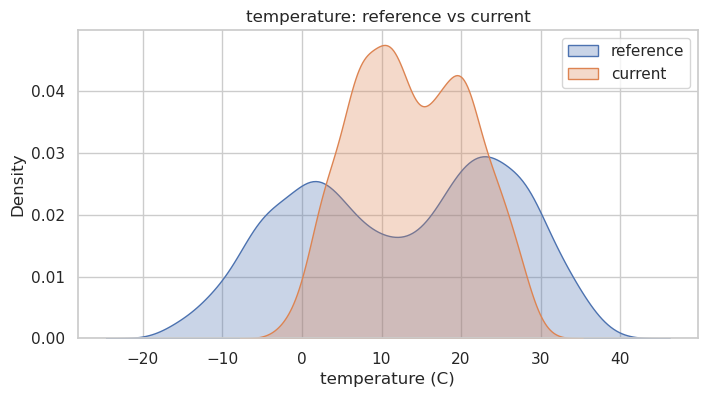

In [3]:
print("reference seasons:", ref["season"].value_counts().to_dict())
print("current seasons:  ", cur["season"].value_counts().to_dict())

plt.figure(figsize=(8, 4))
sns.kdeplot(x=ref["temperature"], label="reference", fill=True, alpha=0.3)
sns.kdeplot(x=cur["temperature"], label="current", fill=True, alpha=0.3)
plt.xlabel("temperature (C)"); plt.legend(); plt.title("temperature: reference vs current");

## does quality hold

Scoring both windows with the serving model. Reference includes the rows the model
trained on, so its error is optimistic — the point isn't the absolute number, it's
the size of the gap to the current window.

In [4]:
def err(frame):
    y, p = frame[TARGET], frame["prediction"]
    return {"mae": mean_absolute_error(y, p), "rmse": mean_squared_error(y, p) ** 0.5}

pd.DataFrame({"reference": err(ref_s), "current": err(cur_s)}).T.round(1)

,mae,rmse
reference,88.6,172.3
current,272.8,359.3


## takeaway

- half the monitored features drift, temperature and the season mix most of all
- error on the current window is well above the reference window
- none of this is a surprise given how the split was drawn — but that's the point:
  the monitor catches a known, explainable shift, which is exactly what should trip
  a retrain. `monitor.py` exits non-zero on this so CI / a cron can react.